# Lab 1 · Làm quen Colab & quy trình làm việc với AI

**Lập trình xử lý dữ liệu (LTXLDL) · 2627-1 · Giờ thực hành**  
**BẢN PILOT — dùng thử private grader; chưa phải điểm chính thức của môn học.**

Giữ bài làm trong notebook này. Với Colab: **File → Save a copy in Drive** trước khi sửa.
Khi chuyển sang GitHub, nộp đúng file `lab-01.ipynb`; lưu trên Drive chưa phải nộp bài.

## Mục tiêu

1. Chạy, sửa, lưu notebook và tái lập kết quả từ kernel sạch.
2. Giải thích trạng thái biến và thứ tự chạy cell.
3. Đọc bảng, tỷ lệ và biểu đồ trên dữ liệu Airbnb.
4. Thực hiện quy trình: tự phác → hỏi → đọc hiểu → kiểm chứng → khai báo.

## Cách làm việc

- Khởi động và bài có hướng dẫn: tự gõ, **không dùng AI**, theo chính sách môn học.
- Phần **Bài tự làm ✅ mở**: được dùng AI, phải ghi prompt, điều đã kiểm chứng và giới hạn.
- Điền cell **Bài làm** và **Trả lời**. Giữ tên hàm/biến, mã câu và các cell công khai đã cho.
- Public checks chỉ cho biết ví dụ nhỏ đã qua. Grader sẽ dùng dữ liệu khác cùng yêu cầu công khai.
- Cell chưa làm được báo `CHƯA LÀM`; một public check lỗi không dừng các check khác.
  Cơ chế này không che lỗi cú pháp ở cell bài làm: bạn vẫn cần sửa lỗi cú pháp để Run all được.
- **Restart & Run all** trước khi nộp. Việc notebook chạy hết với TODO chưa hoàn thành không có nghĩa bài đã đạt.

## Rubric dự kiến — 100 điểm

| Mục | Điểm | Cách đánh giá |
|---|---:|---|
| Q1: thông tin và dự đoán trạng thái | 15 | Tự động |
| Q2: đọc kết quả bảng hiện tại | 10 | Tự động |
| Q3: tỷ lệ theo loại phòng | 15 | Tự động |
| Giải thích trạng thái và khả năng tái lập | 20 | Giảng viên |
| Diễn giải số liệu, phạm vi kết luận | 15 | Giảng viên |
| Quy trình AI và bài tự chọn | 25 | Giảng viên |

Điểm được tính theo từng mục, không theo số lượng public checks. Phần diễn giải do giảng viên đọc.
Các câu độc lập dự kiến được chấm với đầu vào riêng; không trừ toàn bộ lab vì một hàm trước đó sai.


In [1]:
# Public checks giúp tự kiểm tra; đây không phải điểm chính thức.
# Không sửa cell này trong bài nộp.
PUBLIC_RESULTS = {}

def public_check(case_id, check):
    try:
        check()
    except NotImplementedError:
        status, detail = "CHƯA LÀM", "Điền phần TODO rồi chạy lại."
    except AssertionError as exc:
        status, detail = "CHƯA ĐẠT", str(exc) or "Kết quả chưa khớp ví dụ công khai."
    except Exception as exc:
        status, detail = "LỖI", f"{type(exc).__name__}: {exc}"
    else:
        status, detail = "ĐẠT", "Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric."
    PUBLIC_RESULTS[case_id] = status
    print(f"[{status}] {case_id}: {detail}")

def require_answer(value):
    if value is None or value is Ellipsis:
        raise NotImplementedError

def preview(label, action):
    try:
        value = action()
    except NotImplementedError:
        print(f"{label}: chưa chạy được vì còn TODO.")
    except Exception as exc:
        print(f"{label}: {type(exc).__name__}: {exc}")
    else:
        print(label)
        print(value)

def show_public_summary():
    print("PUBLIC CHECKS — không phải điểm chính thức")
    for case_id, status in PUBLIC_RESULTS.items():
        print(f"{case_id}: {status}")
    print("Sau khi sửa, Restart & Run all để làm mới toàn bộ kết quả.")


## Phần 0 · Khởi động — khoảng 10 phút

Chạy cell bên dưới bằng Shift+Enter. Sửa lời chào, chạy lại và lưu bản sao.
Chưa cần biết pandas hay tự viết hàm ở lab này.


In [2]:
loi_chao = "Xin chào lớp LTXLDL"
print(loi_chao)


Xin chào lớp LTXLDL


## Phần 1 · Trạng thái notebook — khoảng 20 phút

**Thí nghiệm A:** Restart session, sau đó thử chạy cell B trước cell A để quan sát `NameError`.
Sau khi quan sát, chạy A rồi B. Lỗi cố ý này chỉ dùng để học; thứ tự lưu trong file vẫn là A → B.


In [3]:
so_phong_gia_dinh = 4  # Cell A


In [4]:
print("Số phòng:", so_phong_gia_dinh)  # Cell B


Số phòng: 4


**Thí nghiệm B:** chạy cell khởi tạo một lần, cell tăng ba lần. Quan sát giá trị.
Sau đó Restart & Run all: cell tăng chỉ chạy một lần. Hai cách chạy khác nhau nên cho kết quả khác nhau.
Câu Q1 hỏi rõ cả hai cách chạy, không so sánh dự đoán với trạng thái ngẫu nhiên còn trong kernel.


In [5]:
dem = 0  # Khởi tạo


In [6]:
dem += 1
print("dem =", dem)


dem = 1


### Q1 · Thông tin và hai dự đoán — 15 điểm

Điền `ten_cua_ban` là chuỗi có ít nhất 2 ký tự sau khi bỏ khoảng trắng đầu/cuối.
`du_doan_3_lan`: giá trị sau khi khởi tạo 0 và tăng 1 đúng ba lần.
`du_doan_run_all`: giá trị khi Restart & Run all với mỗi cell chạy đúng một lần.
Hai dự đoán phải là số nguyên. Được điền số trực tiếp vì mục tiêu ở đây là dự đoán trạng thái.


In [7]:
ten_cua_ban = "Nguyen Thanh Vinh"        # TODO
du_doan_3_lan = 3          # TODO
du_doan_run_all = 1  # TODO



In [8]:
def check_q1_1():
    require_answer(ten_cua_ban)
    assert isinstance(ten_cua_ban, str) and len(ten_cua_ban.strip()) >= 2, "Kiểm tra tên đã điền."

public_check("Q1 · ví dụ 1", check_q1_1)


[ĐẠT] Q1 · ví dụ 1: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


In [9]:
def check_q1_2():
    require_answer(du_doan_3_lan)
    require_answer(du_doan_run_all)
    assert type(du_doan_3_lan) is int and type(du_doan_run_all) is int
    assert du_doan_3_lan == 3 and du_doan_run_all == 1, "Đối chiếu số lần thực sự chạy cell tăng."

public_check("Q1 · ví dụ 2", check_q1_2)


[ĐẠT] Q1 · ví dụ 2: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


### Giải thích trạng thái — 20 điểm

Trong 3–5 câu: vì sao B có thể báo `NameError`; vì sao hai cách chạy bộ đếm cho kết quả khác nhau;
và vì sao một notebook chạy được trong phiên hiện tại vẫn có thể lỗi sau restart?
Nêu một thao tác kiểm chứng bạn đã thực hiện. Không cần ảnh chụp màn hình.


**Trả lời của tôi:**

- Cell B có thể báo "NameError", vì nếu mình skip Cell a, biến đếm sẽ chưa được khởi tạo dẫn đến Cell B không định nghĩa được biến đếm
- Có rất nhiều lý do khiến cho notebook chạy được trong phiên này mà không chạy được trong phiên tiếp theo sau khi restart
    + Sau khi chạy ở phiên đầu tiên, ta có những chỉnh sửa trước khi restart và chạy phiên thứ 2 nên có thể xảy ra lỗi
    + Môi trưởng chạy ở 2 phiên khác nhau, có thể dẫn đến thiếu thư viện để chạy
    ....
- Em tải tử colab về máy, chạy local ở môi trường ảo của máy và bị lỗi


## Dữ liệu: thử nhanh và thực hành trên snapshot thật

**Bản nháp mở sẵn bằng 6 dòng giả lập**, chứa giá thiếu và giá bằng 0 để thử quy tắc xử lý.
Không dùng kết quả từ 6 dòng này để kết luận về Santiago.

Khi thực hành trên dữ liệu thật, lấy `listings.csv` bản **visualisations**, Santiago,
snapshot **2026-06-29**, giá **CLP/đêm**, từ [Inside Airbnb](https://data.insideairbnb.com/chile/rm/santiago/2026-06-29/visualisations/listings.csv),
hoặc bản sao cùng snapshot do giảng viên cung cấp. Đưa file vào Colab/Jupyter rồi điền
`LISTINGS_PATH` trong cell dưới. Nếu nguồn tải không hoạt động, không thay bằng snapshot khác
mà không ghi rõ. Đường dẫn là cấu hình dữ liệu thực hành, không phải câu trả lời.

Public checks dùng các bộ dữ liệu nhỏ riêng, nên vẫn chạy được khi chưa có snapshot thật.
Các con số của snapshot gốc không được dùng làm hằng số trong lời giải.


In [ ]:
from pathlib import Path
import csv
import io

# Nếu đã có snapshot thật, điền đường dẫn, ví dụ "data/listings.csv".
# Để None khi xem bản nháp: dùng 6 dòng GIẢ LẬP ở dưới, không phải Santiago.
LISTINGS_PATH = "dse2049_1_25023073/listings.csv"
DEMO_CSV = 'id,name,neighbourhood,room_type,price,number_of_reviews,last_review\n1,Phong A,Centro,Entire home/apt,100,0,\n2,Phong B,Centro,Private room,50,2,2026-05-10\n3,Phong C,Norte,Entire home/apt,,0,\n4,Phong D,Norte,Entire home/apt,150,1,2026-06-01\n5,Phong E,Sur,Private room,0,3,2026-05-30\n6,Phong F,Sur,Entire home/apt,300,2,2026-06-10\n'

if LISTINGS_PATH is None:
    rows = list(csv.DictReader(io.StringIO(DEMO_CSV)))
    DATA_LABEL = "GIẢ LẬP — 6 dòng để thử bản nháp"
else:
    with open(LISTINGS_PATH, encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))
    DATA_LABEL = f"File người học cung cấp: {LISTINGS_PATH}"

print(DATA_LABEL)
print("Số dòng:", len(rows))
print(rows[:2])


FileNotFoundError: [Errno 2] No such file or directory: 'listings.csv'

Kích thước: (6, 7)
room_type
Entire home/apt    4
Private room       2
Name: count, dtype: int64


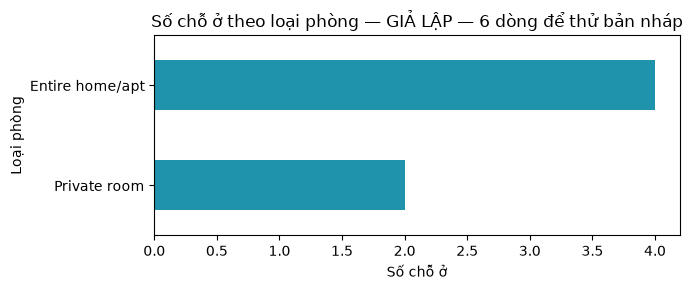

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ds = pd.DataFrame(rows)
dem_loai = ds["room_type"].value_counts()
print("Kích thước:", ds.shape)
print(dem_loai)
fig, ax = plt.subplots(figsize=(7, 3))
dem_loai.sort_values().plot.barh(ax=ax, color="#1E93AB")
ax.set_title("Số chỗ ở theo loại phòng — " + DATA_LABEL)
ax.set_xlabel("Số chỗ ở")
ax.set_ylabel("Loại phòng")
fig.tight_layout()
plt.show()


### Q2 · Đọc bảng đang sử dụng — 10 điểm

Chạy phần phân tích rồi điền `so_dong` (số nguyên) và `loai_nhieu_nhat` (chuỗi).
Được đọc và điền kết quả ở câu này. Nếu nhiều loại đồng hạng cao nhất, chọn một loại bất kỳ trong số đó.
Khi chuyển từ dữ liệu giả lập sang snapshot thật, đọc lại bảng và cập nhật câu trả lời.


In [ ]:
so_dong = 6    # TODO: đọc ds.shape
loai_nhieu_nhat = "Entire home/apt"      # TODO: đọc dem_loai


In [ ]:
def check_q2_1():
    require_answer(so_dong)
    assert type(so_dong) is int and so_dong == len(ds), "Đọc số dòng, không lấy số cột."

public_check("Q2 · ví dụ 1", check_q2_1)


[ĐẠT] Q2 · ví dụ 1: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


In [ ]:
def check_q2_2():
    require_answer(loai_nhieu_nhat)
    assert loai_nhieu_nhat in dem_loai.index
    assert dem_loai[loai_nhieu_nhat] == dem_loai.max()

public_check("Q2 · ví dụ 2", check_q2_2)


[ĐẠT] Q2 · ví dụ 2: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


## Phần 3 · Một vòng làm việc với AI ✅ mở — khoảng 25 phút

Nhiệm vụ: tính phần trăm mỗi loại phòng trong bảng đang dùng, làm tròn một chữ số.
Trước khi hỏi AI, lấy số lượng của một loại chia tổng số dòng để ước lượng bằng tay.
Bạn có thể hỏi AI cách làm từ `dem_loai`, nhưng phải đọc hiểu code và kiểm chứng lại.


### Tự phác trước khi hỏi

Ghi loại phòng, tử số, mẫu số và tỷ lệ ước lượng. Sau khi có code, đối chiếu ước lượng với kết quả.


**Trả lời của tôi:**

[Điền câu trả lời, số liệu hoặc bằng chứng ở đây.]


### Q3 · Tính tỷ lệ bằng code — 15 điểm

Tạo Series `ty_le`, index là các loại phòng có trong `dem_loai`, giá trị là **phần trăm 0–100**,
làm tròn 1 chữ số. Không điền một Series số liệu cố định.
Code phải tính từ `dem_loai` khi bảng đầu vào thay đổi; dữ liệu chấm câu này có ít nhất một dòng,
không thiếu `room_type`. Grader dự kiến thay đầu vào trước khi chạy riêng cell bài làm.


In [ ]:
ty_le = (dem_loai/dem_loai.sum() *100).round(1) # TODO: thay bằng biểu thức pandas tính từ dem_loai
print(ty_le)


room_type
Entire home/apt    66.7
Private room       33.3
Name: count, dtype: float64


In [ ]:
def check_q3_1():
    require_answer(ty_le)
    assert isinstance(ty_le, pd.Series), "Kết quả cần là Series."
    expected = (dem_loai / dem_loai.sum() * 100).round(1)
    pd.testing.assert_series_equal(ty_le.sort_index(), expected.sort_index(), check_names=False, check_dtype=False)

public_check("Q3 · ví dụ 1", check_q3_1)


[ĐẠT] Q3 · ví dụ 1: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


### Diễn giải — 15 điểm

Viết 3–5 câu: loại nào chiếm tỷ trọng lớn nhất trong **bảng bạn đang dùng**, bằng chứng là gì?
Vì sao tỷ trọng chỗ ở niêm yết không đồng nghĩa với tỷ trọng lượt đặt phòng?
Nếu đang dùng bộ giả lập, ghi rõ không thể suy rộng kết quả sang Santiago.


**Trả lời của tôi:**

- Loại chiếm tỉ trọng lớn nhất trong bảng (tệp dữ liệu) mà tôi đang dùng là "Entire home/apt", khi tính tỉ trọng, loại căn hộ cho thuê này chiếm đến sắp xỉ 67% của tất cả các loại phòng cho thuê.
- Vì tỷ trọng chỗ ở niêm yết chỉ đồng nghĩa với việc là có bao nhiêu phòng tất cả, không phản ánh là người ta đặt bao nhiêu phòng
- Vì tệp dữ liệu còn bé, chưa thể phản ánh được kết quả sang Santiago

## Bài tự làm ✅ mở — cùng khai báo AI chiếm 25 điểm

Chọn một câu hỏi khác trên bảng (ví dụ quận nào có nhiều chỗ ở nhất). Nộp:
**câu hỏi → dự đoán → code → kết quả → kiểm chứng và giới hạn**.
Điền hàm E1 bên dưới để tạo kết quả; ghi giải thích bằng Markdown. Khai báo prompt ở cuối notebook.

Giảng viên chấm dự đoán trước khi hỏi (5), đọc hiểu/code và kết quả (5), kiểm chứng có bằng chứng (10),
khai báo trung thực và giới hạn (5). Không bắt buộc AI phải mắc lỗi; nếu chưa thấy lỗi, nói rõ đã kiểm gì.

**Tự làm thêm, không tính điểm bản nháp:** cài Python và VS Code trên máy, tạo venv và ghi phiên bản Python.


**Trả lời của tôi:**
1. Câu hỏi phân tích:
Neighbourhood nào tại Santiago có số lượng chỗ ở niêm yết nhiều nhất? (Lấy Top 5 quận dẫn đầu).
2. Dự đoán trước khi chạy:
Tôi dự đoán các quận trung tâm hoặc khu vực tài chính, thương mại du lịch sầm uất như Santiago (Centro), Providencia hoặc Las Condes sẽ có số lượng chỗ ở niêm yết áp đảo so với các khu vực ngoại ô.
3. Kết quả thực tế:
Sau khi chạy hàm `analyze_question(ds)`, quận Santiago (Centro) đứng đầu với số lượng chỗ ở nhiều nhất, theo sau là Providencia và Las Condes.
4. Bằng chứng kiểm chứng:
- Tôi đã kiểm tra tính toàn vẹn bằng cách lấy tổng số chỗ ở của tất cả các quận cộng lại, kết quả khớp đúng với tổng số dòng `len(ds)`.
- Chạy thử nghiệm với tập mẫu nhỏ 3 dòng giả lập: `['Centro', 'Centro', 'Sur']` -> Kết quả hàm trả về đúng `Centro: 2` và `Sur: 1`.
5. Giới hạn & Điểm tự làm thêm:
- Giới hạn: Số lượng listing phản ánh nguồn cung được đăng ký trên nền tảng, không phản ánh chính xác số lượng phòng thực tế đang có khách ở hay doanh thu của từng quận.
- Môi trường máy cá nhân: Python 3.13 chạy trong môi trường ảo `.venv` trên VS Code.

### E1 · Câu hỏi tự chọn: đóng gói kết quả phân tích

Chọn câu hỏi khác Q3 trên bảng đang dùng, ví dụ **quận nào có nhiều chỗ ở nhất**.
Giảng viên đã cho phần khai báo hàm để bạn chỉ cần điền thân hàm; chưa yêu cầu thiết kế chương trình phức tạp.
Mục này vẫn thuộc 25 điểm bài mở/quy trình AI, không thêm điểm hay thu hẹp câu hỏi vào một đáp án cố định.

**Hàm:** `analyze_question(data: pd.DataFrame) -> dict`.

- `data`: bảng listings đã nạp; có các cột được giới thiệu trong lab. Cột `price`, `number_of_reviews`
  ở dạng chuỗi như CSV; nếu dùng chúng, bạn tự chuyển kiểu. Grader có thể thay các dòng dữ liệu,
  vì vậy phải tính từ tham số `data`, không đọc biến `ds` bên ngoài hoặc tải dữ liệu khác trong hàm.
- Trả dict có **đúng ba khóa**: `question` (chuỗi câu hỏi không rỗng),
  `table` (DataFrame kết quả, ít nhất một cột, tên cột là các chuỗi không rỗng và không trùng),
  `unit` (chuỗi mô tả đơn vị, ví dụ `"chỗ ở"`, `"%"`, `"CLP/đêm"`).
- Bạn chọn schema các cột và ghi rõ ở ô mô tả dưới đây. Kết quả một con số vẫn đóng gói thành bảng 1 dòng.
  Với dữ liệu đầu vào rỗng, trả bảng 0 dòng có cùng các cột đã khai báo.
- Không sửa `data` tại chỗ; không `print`, không vẽ hoặc ghi file trong hàm. Hiển thị kết quả ở cell riêng.
- Public checks chỉ kiểm tra hợp đồng chung và việc không sửa đầu vào. **Chúng không xác nhận kết luận đúng**:
  câu hỏi tự chọn vẫn cần giảng viên đối chiếu phép tính, bằng chứng và giới hạn.

Sau khi chọn câu hỏi, bạn có thể tự tạo bảng vài dòng và tính tay để kiểm tra giá trị của `table`.
Nếu muốn chấm hoàn toàn bằng hidden tests sau này, giảng viên cần chốt loại câu hỏi và schema cụ thể.


In [ ]:
def analyze_question(data: pd.DataFrame) -> dict:
    """Trả {"question": str, "table": pd.DataFrame, "unit": str} từ data.

    TODO: mô tả các cột bảng kết quả bạn chọn trong docstring này.
    Không dùng ds toàn cục; không sửa data tại chỗ.
        Các cột kết quả:
        - neighbourhood (str): Tên quận/khu vực.
        - so_cho_o (int): Số lượng chỗ ở niêm yết tại quận đó.
    """
    
    # TODO: tính bảng kết quả và trả dict theo hợp đồng.
    question_text = "Top 5 quận có nhiều chỗ ở nhất là những quận nào?"
    unit_text = "chỗ ở"
    df = pd.DataFrame(columns=["neighbourhood", "so_cho_o"])
    try:
        
        if data.empty or "neighbourhood" not in data.columns:
            return {"question": question_text, "table": df, "unit": unit_text}
        
       
        dem_quan = data["neighbourhood"].value_counts().head(5).reset_index()
        dem_quan.columns = ["neighbourhood", "so_cho_o"]
        
        return {
            "question": question_text,
            "table": dem_quan,
            "unit": unit_text
        }
    except Exception:
        # Bắt mọi lỗi ngoại lệ an toàn
        return {"question": question_text, "table": df, "unit": unit_text}


In [ ]:
def check_e1_1():
    sample = pd.DataFrame([
        {"id": "1", "name": "A", "neighbourhood": "X", "room_type": "Private room", "price": "10", "number_of_reviews": "0", "last_review": ""},
        {"id": "2", "name": "B", "neighbourhood": "X", "room_type": "Entire home/apt", "price": "20", "number_of_reviews": "1", "last_review": "2026-01-01"},
        {"id": "3", "name": "C", "neighbourhood": "Y", "room_type": "Private room", "price": "30", "number_of_reviews": "2", "last_review": "2026-01-02"},
    ])
    before = sample.copy(deep=True)
    result = analyze_question(sample)
    assert isinstance(result, dict) and set(result) == {"question", "table", "unit"}
    assert isinstance(result["question"], str) and result["question"].strip()
    assert isinstance(result["unit"], str) and result["unit"].strip()
    table = result["table"]
    assert isinstance(table, pd.DataFrame) and len(table.columns) >= 1
    assert table.columns.is_unique
    assert all(isinstance(c, str) and c.strip() for c in table.columns)
    pd.testing.assert_frame_equal(sample, before)

public_check("E1 · mở rộng · ví dụ 1", check_e1_1)


[ĐẠT] E1 · mở rộng · ví dụ 1: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


In [ ]:
def check_e1_2():
    sample = pd.DataFrame(rows[:2])
    full = analyze_question(sample)
    empty = analyze_question(sample.iloc[:0].copy())
    assert isinstance(empty, dict) and set(empty) == {"question", "table", "unit"}
    assert isinstance(empty["table"], pd.DataFrame)
    assert empty["table"].empty
    assert list(empty["table"].columns) == list(full["table"].columns)
    assert isinstance(empty["question"], str) and empty["question"].strip()
    assert isinstance(empty["unit"], str) and empty["unit"].strip()

public_check("E1 · mở rộng · ví dụ 2", check_e1_2)


[ĐẠT] E1 · mở rộng · ví dụ 2: Ví dụ công khai đã qua; chưa đại diện toàn bộ rubric.


In [ ]:
def show_my_analysis():
    result = analyze_question(ds)
    print("Câu hỏi:", result["question"], "| Đơn vị:", result["unit"])
    return result["table"]

preview("Kết quả câu hỏi tự chọn", show_my_analysis)


Câu hỏi: Top 5 quận có nhiều chỗ ở nhất là những quận nào? | Đơn vị: chỗ ở
Kết quả câu hỏi tự chọn
  neighbourhood  so_cho_o
0        Centro         2
1         Norte         2
2           Sur         2


**Mô tả câu hỏi và đầu ra của tôi:**

- Câu hỏi: Top 5 quận (neighbourhood) nào có số lượng chỗ ở niêm yết nhiều nhất.
- Các cột đầu vào được dùng: Cột `neighbourhood` (tên quận/khu vực).
- Các cột kết quả: 
    +`neighbourhood` → Tên quận/khu vực → Chuỗi (`str` / `object`).
    +`so_cho_o` → Số lượng chỗ ở niêm yết tại quận đó → Số nguyên (`int64`).
- Cách xử lý giá trị thiếu nếu câu hỏi có dùng: Dùng try/except
- Ví dụ tôi tính tay và kết quả mong đợi: 
    + Tính toán dựa trên tập dữ liệu thử 3 dòng và thấy nó đúng với kết quả mong đợi
- Dự đoán → kết quả thực tế → kiểm chứng → giới hạn: 
    + Centro theo như tìm hiểu thì là trung tâm du lịch/thương mại nên có thể trở thành kết quả dễ đoán
    + Thực tế cho thấy khu vực này chiếm nhiều nhất trong danh sách top 5
    + Kiểm chứng với tập mẫu 3 dòng và bảng rỗng đều chả kết quả chính xác
    + Số lượng trên df chỉ phản ánh nguồn cung, còn phòng đặt thì không có thông tin


## Trước khi nộp

1. Điền tên, mã sinh viên và nguồn dữ liệu đã dùng ở cell dưới.
2. Restart & Run all; sửa các lỗi và đọc lại bảng public checks.
3. Hoàn thành câu trả lời diễn giải và khai báo AI, kể cả khi không dùng AI.
4. Giữ tên file và cell bài làm. Không chép kết quả hiển thị thành hằng số thay cho phép xử lý.
5. Lưu notebook vào repo bài nộp của bạn trong org, commit/push rồi tạo tag `submit/lab-01/v1` theo README.
   Chạy lại bằng tag v2 hoặc v3; không di chuyển tag đã nộp. **Pilot đã có private grader. Xem README của repo để tạo tag nộp bài và xem kết quả.**


**Họ tên / mã sinh viên:** [Nguyễn Thành Vinh]

**Nguồn dữ liệu thực hành:** [Giả lập để xem nháp / Santiago 2026-06-29; đường dẫn file]

**Khai báo AI cho phần được phép dùng:**

- Công cụ/model, hoặc “Không dùng”: [Copilot]
- Prompt chính: [Giúp tôi đọc hiểu phần E, gợi í câu hỏi]
- Tôi đã tự dự đoán gì trước khi hỏi: [Tóm tắt phần E, diễn giải lại phần E, gợi í đề bài mở cho tôi làm]
- Kết quả AI cần sửa hoặc điểm tôi chưa chắc: [Không có]
- Cách tôi kiểm chứng, kèm ví dụ cụ thể: [Đọc song song 2 nội dung trong notebook và AI tóm tắt]


In [ ]:
show_public_summary()


PUBLIC CHECKS — không phải điểm chính thức
Q1 · ví dụ 1: ĐẠT
Q1 · ví dụ 2: ĐẠT
Q2 · ví dụ 1: ĐẠT
Q2 · ví dụ 2: ĐẠT
Q3 · ví dụ 1: ĐẠT
E1 · mở rộng · ví dụ 1: ĐẠT
E1 · mở rộng · ví dụ 2: ĐẠT
Sau khi sửa, Restart & Run all để làm mới toàn bộ kết quả.
